# DSAI LAB 9 PROSHITA AGARWAL

### PART 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("ChurnData.csv")
print(df.head())

   tenure  age  address  income  ed  employ  equip  callcard  wireless  \
0      11   33        7     136   5       5      0         1         1   
1      33   33       12      33   2       0      0         0         0   
2      23   30        9      30   1       2      0         0         0   
3      38   35        5      76   2      10      1         1         1   
4       7   35       14      80   2      15      0         1         0   

   longmon  ...  pager  internet  callwait  confer  ebill  loglong  logtoll  \
0     4.40  ...      1         0         1       1      0    1.482    3.033   
1     9.45  ...      0         0         0       0      0    2.246    3.240   
2     6.30  ...      0         0         0       1      0    1.841    3.240   
3     6.05  ...      1         1         1       1      1    1.800    3.807   
4     7.10  ...      0         0         1       1      0    1.960    3.091   

   lninc  custcat  churn  
0  4.913        4      1  
1  3.497        1      1  

In [3]:
df = df.dropna()
df = df.drop_duplicates()

df.reset_index(drop=True, inplace=True)

print("\nCleaned Data Overview:")
print(df.info())
print("\nFirst few rows of cleaned data:")
print(df.head())


Cleaned Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 28 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tenure    200 non-null    int64  
 1   age       200 non-null    int64  
 2   address   200 non-null    int64  
 3   income    200 non-null    int64  
 4   ed        200 non-null    int64  
 5   employ    200 non-null    int64  
 6   equip     200 non-null    int64  
 7   callcard  200 non-null    int64  
 8   wireless  200 non-null    int64  
 9   longmon   200 non-null    float64
 10  tollmon   200 non-null    float64
 11  equipmon  200 non-null    float64
 12  cardmon   200 non-null    float64
 13  wiremon   200 non-null    float64
 14  longten   200 non-null    float64
 15  tollten   200 non-null    float64
 16  cardten   200 non-null    float64
 17  voice     200 non-null    int64  
 18  pager     200 non-null    int64  
 19  internet  200 non-null    int64  
 20  callwait

In [5]:
feature_cols = ['tenure', 'age', 'address', 'income', 'employ', 'equip', 'callcard']
X = df[feature_cols]
y = df['churn']

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Normalization ensures all variables are on a similar scale, improving model convergence and stability.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=4)

The dataset is split into 80% for training and 20% for testing to evaluate how well the model generalizes to unseen data.

In [8]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
LR = LogisticRegression(C=0.01, solver='liblinear')
LR.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


We used liblinear as the optimizer and fixed the regularization strength at C = 0.01 to prevent overfitting. Logistic Regression helps estimate the probability that a customer will churn.

In [9]:
# Predict probabilities for test data
y_prob = LR.predict_proba(X_test)

# Display first few predicted probabilities
print(y_prob[:5])

[[0.56845922 0.43154078]
 [0.60679253 0.39320747]
 [0.50206039 0.49793961]
 [0.65208859 0.34791141]
 [0.51315131 0.48684869]]


The model outputs two probabilities per observation:

Column 1: P(Y = 0 | X) → Probability of customer staying

Column 2: P(Y = 1 | X) → Probability of customer leaving

These probabilities help the company identify customers most likely to churn and target them with retention efforts.

### PART 2

In [10]:
from sklearn.metrics import log_loss

# Predict probabilities for the test data
y_prob = LR.predict_proba(X_test)

# Compute log loss
loss = log_loss(y_test, y_prob)
print("Log Loss:", loss)

Log Loss: 0.5977738365984958


Log loss measures how close the predicted probabilities are to the true labels.
A lower log loss means better performance.
Since churn prediction is probabilistic (how likely a customer will leave), log loss is a more informative metric than just accuracy, it rewards confident and correct predictions.

In [11]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Predict final labels
y_pred = LR.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification metrics
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Confusion Matrix:
 [[22  3]
 [ 8  7]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.88      0.80        25
           1       0.70      0.47      0.56        15

    accuracy                           0.72        40
   macro avg       0.72      0.67      0.68        40
weighted avg       0.72      0.72      0.71        40

Accuracy: 0.725


Confusion Matrix:

Shows how many churners were correctly predicted vs. misclassified.

Format →


[[True Negatives    False Positives]

 [False Negatives   True Positives]]



Accuracy:

Measures how many total predictions were correct.


Precision:

Of the customers predicted to churn, how many actually churned?


Recall (Sensitivity):

Of all actual churners, how many did the model catch?


F1-Score:

A balance between precision and recall, especially useful if data is imbalanced (i.e., fewer churners).

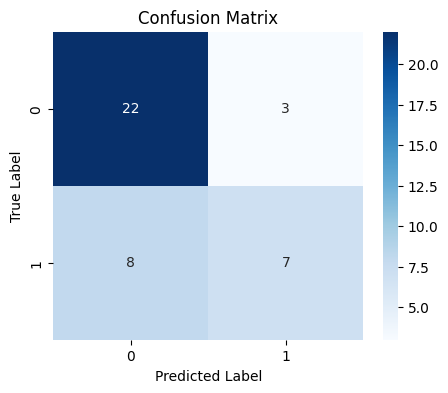

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### INTERPRETATION:

In churn prediction, recall and F1-score are more important than overall accuracy.
We’d rather identify as many potential churners as possible, even if a few non-churners are incorrectly flagged.
This allows the company to take preventive actions like offering discounts or personalized plans to at-risk customers.